In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
from scipy.stats import chi2_contingency

In [89]:
df = pd.read_parquet("../data/derived/clean_core.parquet")

In [90]:
pd.set_option('display.max_rows', None)
null_pct = df.isnull().mean().mul(100).round(2).reset_index()
null_pct.columns = ['column', 'null_pct']
display(null_pct.sort_values('null_pct', ascending=False))

,column,null_pct
14,employment_addl,93.99
52,current_tech,90.47
74,job_sat_num,87.11
42,work_week_hrs_clean,85.94
41,work_week_hrs,85.84
33,ic_or_pm,80.84
34,ic_or_pm_clean,80.84
69,work_exp_clean,79.53
68,work_exp,79.51
37,industry_clean,79.25


In [91]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

/var/folders/9b/jyss1xc93y77hbkw1rh8mlmm0000gn/T/ipykernel_36049/1488647755.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mul(100).round(2))


survey_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
survey_year,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
response_id,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country,3.09,0.90,0.00,0.42,0.15,0.60,0.00,2.04,1.36,9.94,27.96
country_clean,3.11,0.95,0.27,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
region,3.11,0.95,0.31,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
age,0.98,1.24,100.00,34.68,10.88,29.50,1.24,3.17,0.00,0.00,0.00
age_mid,2.28,1.24,100.00,36.34,10.95,29.54,8.37,9.16,5.13,4.42,0.77
age_group,2.28,1.24,100.00,36.34,10.95,29.54,8.37,9.16,5.13,4.42,0.77
gender,1.31,0.79,31.80,34.78,3.91,21.57,1.38,3.30,100.00,100.00,100.00


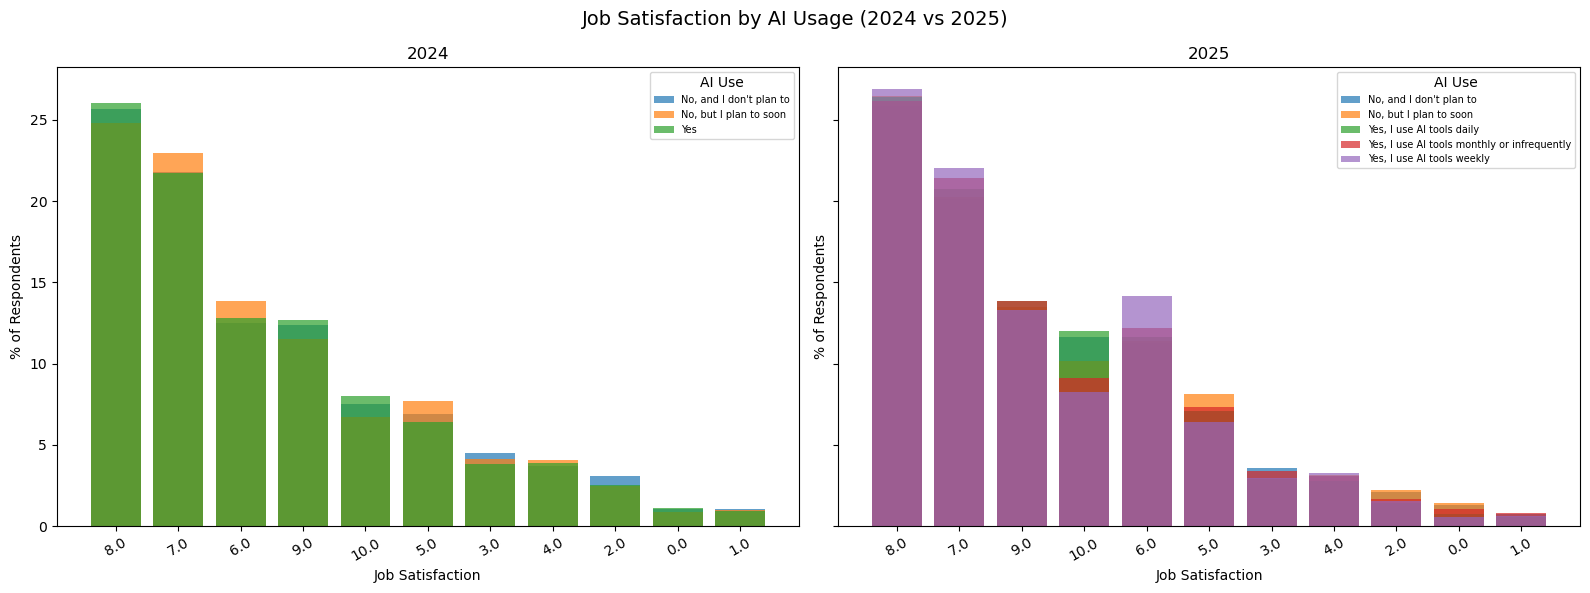

In [92]:
ai_sat = df[
    df['survey_year'].isin([2024, 2025])
    & df['ai_use'].notna()
    & df['job_sat'].notna()
].copy()

sat_by_ai = (
    ai_sat.groupby(['survey_year', 'ai_use'])['job_sat']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name='pct')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Job Satisfaction by AI Usage (2024 vs 2025)', fontsize=14)

for ax, year in zip(axes, [2024, 2025]):
    subset = sat_by_ai[sat_by_ai['survey_year'] == year]
    for ai_group, grp in subset.groupby('ai_use'):
        ax.bar(grp['job_sat'], grp['pct'], label=ai_group, alpha=0.7)
    ax.set_title(str(year))
    ax.set_xlabel('Job Satisfaction')
    ax.set_ylabel('% of Respondents')
    ax.legend(title='AI Use', fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [93]:
cols_to_drop = [
    # Never or barely available across years
    'ethnicity',
    'student',
    'undergrad_major',
    'age_first_code',
    'age_first_code_clean',
    'job_seek',
    'work_week_hrs',
    'work_week_hrs_clean',
    'learn_code_online',
    'learn_code_online_count',
    'coding_activities',
    'coding_activities_count',
    'misc_tech',
    'misc_tech_count',
    'webframe',
    'webframe_count',
    'op_sys_prof',
    'op_sys_prof_count',
    'current_tech',
    'ai_use',
    'ai_sent',
    
    'learn_code',
    'learn_code_count',
    'work_exp',
    'age_mid',
    

    'cpi_u',
    'is_comp_analysis_sample',
    'is_comp_model_core',
    'is_comp_model_tech_rich',
    'is_comp_model_ai_era',
    'is_comp_model_extended',
    'is_comp_model_sample',
    'response_id',
    'main_branch',
    'gender',
    'country'
    
    

  
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Columns remaining: 69
['row_id', 'survey_year', 'country_clean', 'region', 'age', 'age_group', 'employment', 'employment_addl', 'employment_primary', 'employment_group', 'is_employed', 'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed', 'is_independent', 'is_student_status', 'is_retired_status', 'is_not_employed', 'is_professional', 'education', 'education_clean', 'org_size', 'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry', 'industry_clean', 'remote', 'remote_group', 'language', 'database', 'platform', 'language_count', 'database_count', 'platform_count', 'years_code', 'years_code_clean', 'years_code_pro', 'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_years', 'experience_proxy_source', 'professional_experience_years', 'job_sat', 'job_sat_num', 'comp', 'comp_usd_clean', 'log_comp_usd_clean', 'comp_real_2025', 'log_comp_real_2025', 'role_family_count', 'role_advocacy_dx', 'role_architecture', 'role_back_end', 'role_data_ml', 'role_desi

In [94]:
df_clean = df_clean[~df_clean['survey_year'].isin([2021, 2022, 2023])]
print(df_clean['survey_year'].unique())
print(f"Rows remaining: {len(df_clean):,}")

[2015 2016 2017 2018 2019 2020 2024 2025]
Rows remaining: 500,335


In [95]:
for year in sorted(df_clean['survey_year'].unique()):
    unique_vals = df_clean[df_clean['survey_year'] == year]['job_sat'].dropna().unique()
    print(f"\n{year}:")
    for val in unique_vals:
        print(f"  {val}")


2015:
  I'm somewhat satisfied with my job
  I'm neither satisfied nor dissatisfied with my job
  I love my job
  I'm somewhat dissatisfied with my job
  I hate my job
  Other (please specify)

2016:
  I love my job
  I don't have a job
  I'm somewhat satisfied with my job
  I'm somewhat dissatisfied with my job
  I'm neither satisfied nor dissatisfied
  Other (please specify)
  I hate my job

2017:
  9.0
  3.0
  8.0
  6.0
  7.0
  5.0
  4.0
  10.0
  2.0
  0.0
  1.0

2018:
  Extremely satisfied
  Moderately dissatisfied
  Moderately satisfied
  Neither satisfied nor dissatisfied
  Slightly satisfied
  Slightly dissatisfied
  Extremely dissatisfied

2019:
  Slightly satisfied
  Slightly dissatisfied
  Neither satisfied nor dissatisfied
  Very satisfied
  Very dissatisfied

2020:
  Slightly satisfied
  Very dissatisfied
  Slightly dissatisfied
  Very satisfied
  Neither satisfied nor dissatisfied

2024:
  8.0
  5.0
  10.0
  6.0
  9.0
  4.0
  7.0
  3.0
  2.0
  1.0
  0.0

2025:
  10.0
  9.

In [96]:
# Map all years to a consistent 1-5 ordinal scale:
#   1 = Very Dissatisfied  2 = Dissatisfied  3 = Neutral  4 = Satisfied  5 = Very Satisfied
#
# 2015/2016: 5-point text  |  2018: 7-point text (collapsed to 5)
# 2019/2020: 5-point text  |  2017/2024/2025: 0-10 numeric (binned)

SAT_MAP = {
    # 2015 & 2016
    "I hate my job":                                         1,
    "I'm somewhat dissatisfied with my job":                2,
    "I'm neither satisfied nor dissatisfied with my job":   3,
    "I'm neither satisfied nor dissatisfied":               3,
    "I'm somewhat satisfied with my job":                   4,
    "I love my job":                                         5,
    "I don't have a job":                                   np.nan,
    "Other (please specify)":                                np.nan,

    # 2018 (7-point collapsed to 5)
    "Extremely dissatisfied":           1,
    "Moderately dissatisfied":          2,
    "Slightly dissatisfied":            2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied":               4,
    "Moderately satisfied":             4,
    "Extremely satisfied":              5,

    # 2019 & 2020
    "Very dissatisfied":    1,
    # "Slightly dissatisfied" already mapped above
    # "Neither satisfied nor dissatisfied" already mapped above
    # "Slightly satisfied" already mapped above
    "Very satisfied":       5,
}

def standardize_job_sat(row):
    val = row["job_sat"]
    year = row["survey_year"]

    if pd.isna(val):
        return np.nan

    # 2017, 2024, 2025: 0-10 numeric â€” bin to 1-5
    if year in [2017, 2024, 2025]:
        try:
            v = float(val)
        except:
            return np.nan
        if v <= 1:   return 1
        elif v <= 4: return 2
        elif v <= 6: return 3
        elif v <= 8: return 4
        else:        return 5

    return SAT_MAP.get(val, np.nan)

df_clean["job_sat_std"] = df_clean.apply(standardize_job_sat, axis=1)

# Sanity check
print(df_clean.groupby("survey_year")["job_sat_std"].agg(["mean", "median", "count"]))
print()
print(df_clean["job_sat_std"].value_counts().sort_index())


                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670

job_sat_std
1.0     14057
2.0     46836
3.0     44968
4.0    140509
5.0     90689
Name: count, dtype: int64


In [97]:
df_model = df_clean[df_clean['job_sat_std'].notna()].copy()

print(f"Rows before: {len(df_clean):,}")
print(f"Rows after:  {len(df_model):,}")
print(f"Dropped:     {len(df_clean) - len(df_model):,}")
print()
print(df_model.groupby('survey_year')['job_sat_std'].agg(['mean', 'median', 'count']))

Rows before: 500,335
Rows after:  337,059
Dropped:     163,276

                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670


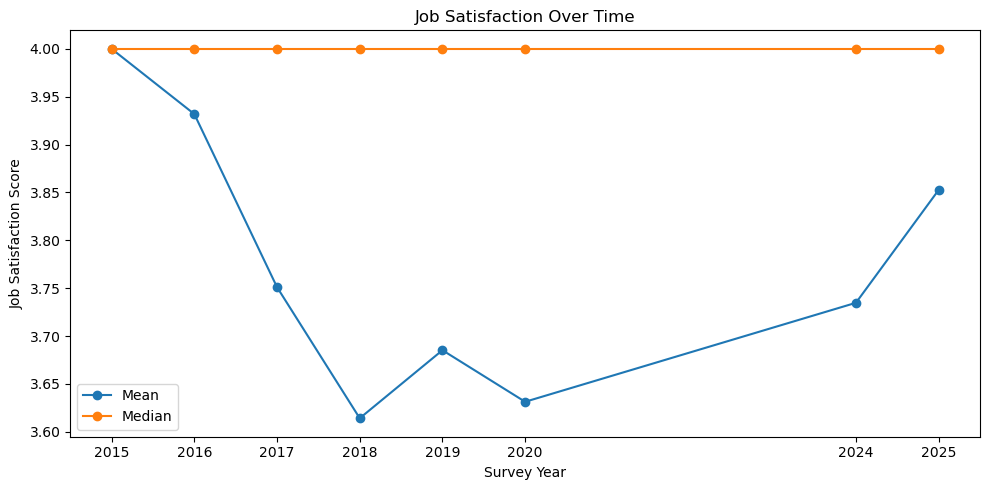

In [98]:
sat_by_year = (
    df_model.groupby('survey_year')['job_sat_std']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sat_by_year['survey_year'], sat_by_year['mean'], marker='o', label='Mean')
ax.plot(sat_by_year['survey_year'], sat_by_year['median'], marker='o', label='Median')

ax.set_title('Job Satisfaction Over Time')
ax.set_xlabel('Survey Year')
ax.set_ylabel('Job Satisfaction Score')
ax.legend()
ax.set_xticks(sat_by_year['survey_year'])
plt.tight_layout()
plt.show()

In [99]:
print(df_model.groupby('survey_year').agg(
    total_rows=('job_sat', 'size'),
    non_null=('job_sat_std', lambda x: x.notna().sum()),
    null=('job_sat_std', lambda x: x.isna().sum()),
    pct_null=('job_sat_std', lambda x: round(x.isna().mean() * 100, 2)),
    mean_sat=('job_sat_std', 'mean'),
    median_sat=('job_sat_std', 'median'),
))

             total_rows  non_null  null  pct_null  mean_sat  median_sat
survey_year                                                            
2015              16004     16004     0       0.0  3.999938         4.0
2016              39425     39425     0       0.0  3.931820         4.0
2017              40376     40376     0       0.0  3.751090         4.0
2018              69276     69276     0       0.0  3.614210         4.0
2019              70988     70988     0       0.0  3.685257         4.0
2020              45194     45194     0       0.0  3.631411         4.0
2024              29126     29126     0       0.0  3.734773         4.0
2025              26670     26670     0       0.0  3.852606         4.0


In [100]:
df_clean['sat_missing'] = df_clean['job_sat_std'].isna().astype(int)
print(df_clean.groupby('survey_year')['sat_missing'].mean())
print(df_clean.groupby('employment_group')['sat_missing'].mean())
print(df_clean.groupby('region')['sat_missing'].mean())

survey_year
2015    0.386491
2016    0.296359
2017    0.214352
2018    0.299216
2019    0.201332
2020    0.298894
2024    0.554900
2025    0.457828
Name: sat_missing, dtype: float64
employment_group
Employed full-time        0.181238
Employed part-time        0.384047
Independent / contract    0.274349
Not employed              0.956048
Other                     0.744584
Retired                   0.961205
Student                   0.977950
Name: sat_missing, dtype: float64
region
Africa      0.437049
Americas    0.255103
Asia        0.365735
Europe      0.284995
Oceania     0.268346
Name: sat_missing, dtype: float64


mostly full-time employed professionals, 

by removing all job_sat that are null, we can see that 97% of students and unemployed left job sat na. 
additionally almost half of people from africa left job_sat NA
modeling will underrepresent these groups 

In [101]:
null_by_year = (
    df_model.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

/var/folders/9b/jyss1xc93y77hbkw1rh8mlmm0000gn/T/ipykernel_36049/970056642.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mul(100).round(2))


survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
survey_year,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,1.26,0.41,0.13,0.07,0.13,0.05,0.04,3.15
region,1.26,0.41,0.15,0.07,0.13,0.05,0.04,3.15
age,0.22,0.55,100.00,19.64,8.96,19.56,0.00,0.00
age_group,0.90,0.55,100.00,20.11,9.01,19.59,0.42,0.26
employment,0.22,0.11,0.00,0.00,0.47,0.28,0.00,0.00
employment_addl,100.00,100.00,100.00,100.00,100.00,100.00,100.00,5.78
employment_primary,0.22,0.11,0.00,0.00,0.08,0.28,0.00,0.00
employment_group,0.22,0.11,0.00,0.00,0.08,0.28,0.00,0.00


In [102]:
overall_null = df_model.isnull().mean().mul(100).round(2).reset_index()
overall_null.columns = ['column', 'overall_null_pct']
overall_null = overall_null.sort_values('overall_null_pct', ascending=False)

# flag columns over 50% null overall
majority_null = overall_null[overall_null['overall_null_pct'] > 50]
print("Columns with >50% nulls overall:")
print(majority_null.to_string(index=False))

Columns with >50% nulls overall:
         column  overall_null_pct
employment_addl             92.54
 ic_or_pm_clean             84.71
       ic_or_pm             84.71
 work_exp_clean             83.70
    job_sat_num             71.47
 industry_clean             67.71
       industry             56.91


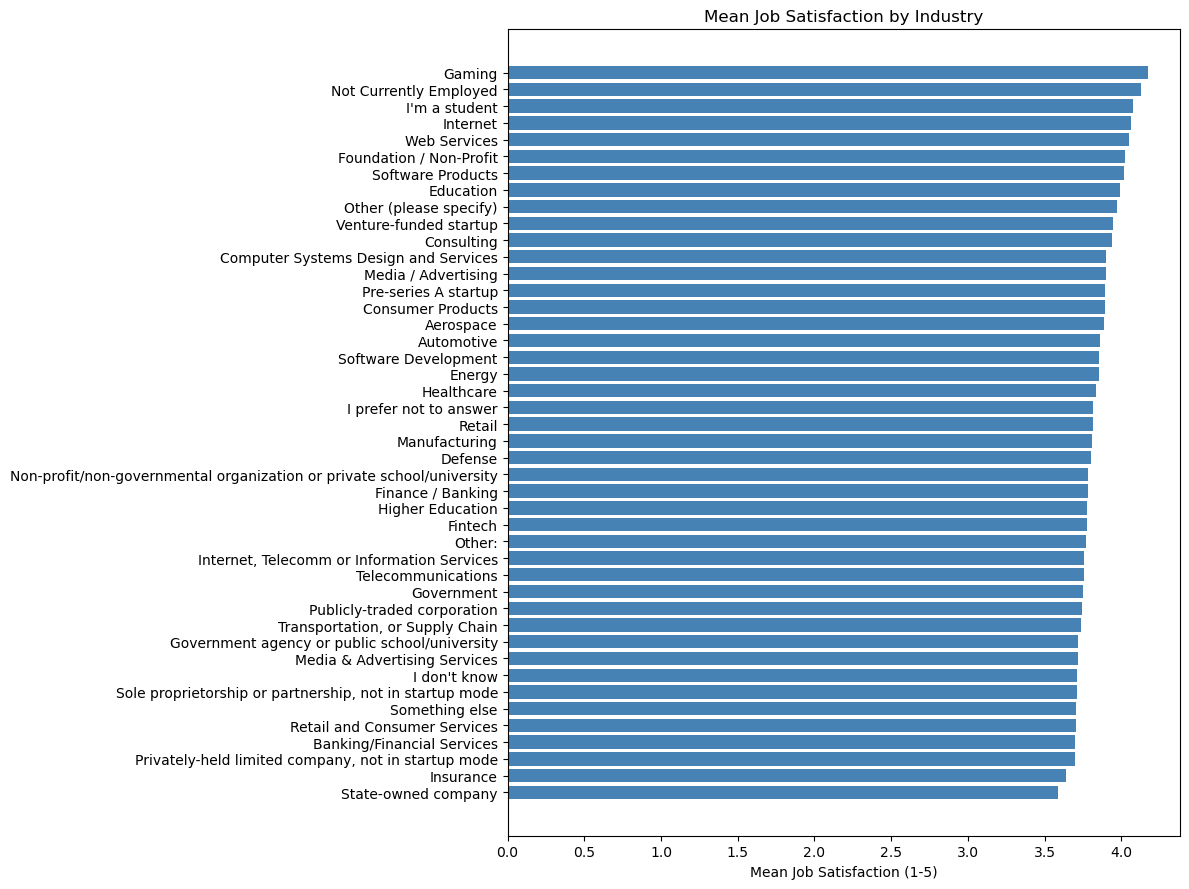

In [103]:
industry_sat = (
    df_model[df_model['industry'].notna()]
    .groupby('industry')['job_sat_std']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(industry_sat['industry'], industry_sat['job_sat_std'], color='steelblue')
ax.set_title('Mean Job Satisfaction by Industry')
ax.set_xlabel('Mean Job Satisfaction (1-5)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [104]:
cols_to_drop = [
    # Non-features
    "row_id",
    "country_clean",       # too granular; region already captures geography

    # Raw target variants (keep job_sat_std)
    "job_sat",
    "job_sat_num",         # 71.5% null

    # Redundant — raw versions superseded by cleaned columns
    "age",                 # 100% null in 2017; use age_group
    "employment",          # use employment_group
    "education",           # use education_clean
    "org_size",            # use org_size_clean
    "remote",              # use remote_group
    "years_code",          # use years_code_clean

    # Redundant compensation columns (keep log_comp_real_2025)
    "comp",
    "comp_usd_clean",
    "log_comp_usd_clean",
    "comp_real_2025",

    #'years_code_pro_clean

    # Raw multi-select strings (keep *_count columns)
    "language",
    "database",
    "platform",
]

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])
print(f"Columns remaining: {len(df_model.columns)}")
print(df_model.columns.tolist())


Columns remaining: 53
['survey_year', 'region', 'age_group', 'employment_addl', 'employment_primary', 'employment_group', 'is_employed', 'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed', 'is_independent', 'is_student_status', 'is_retired_status', 'is_not_employed', 'is_professional', 'education_clean', 'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry', 'industry_clean', 'remote_group', 'language_count', 'database_count', 'platform_count', 'years_code_clean', 'years_code_pro', 'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_years', 'experience_proxy_source', 'professional_experience_years', 'log_comp_real_2025', 'role_family_count', 'role_advocacy_dx', 'role_architecture', 'role_back_end', 'role_data_ml', 'role_design_ux', 'role_desktop_enterprise', 'role_devops_cloud', 'role_embedded_hardware', 'role_front_end', 'role_full_stack', 'role_game_graphics', 'role_management', 'role_mobile', 'role_other', 'role_qa_testing', 'role_security', 

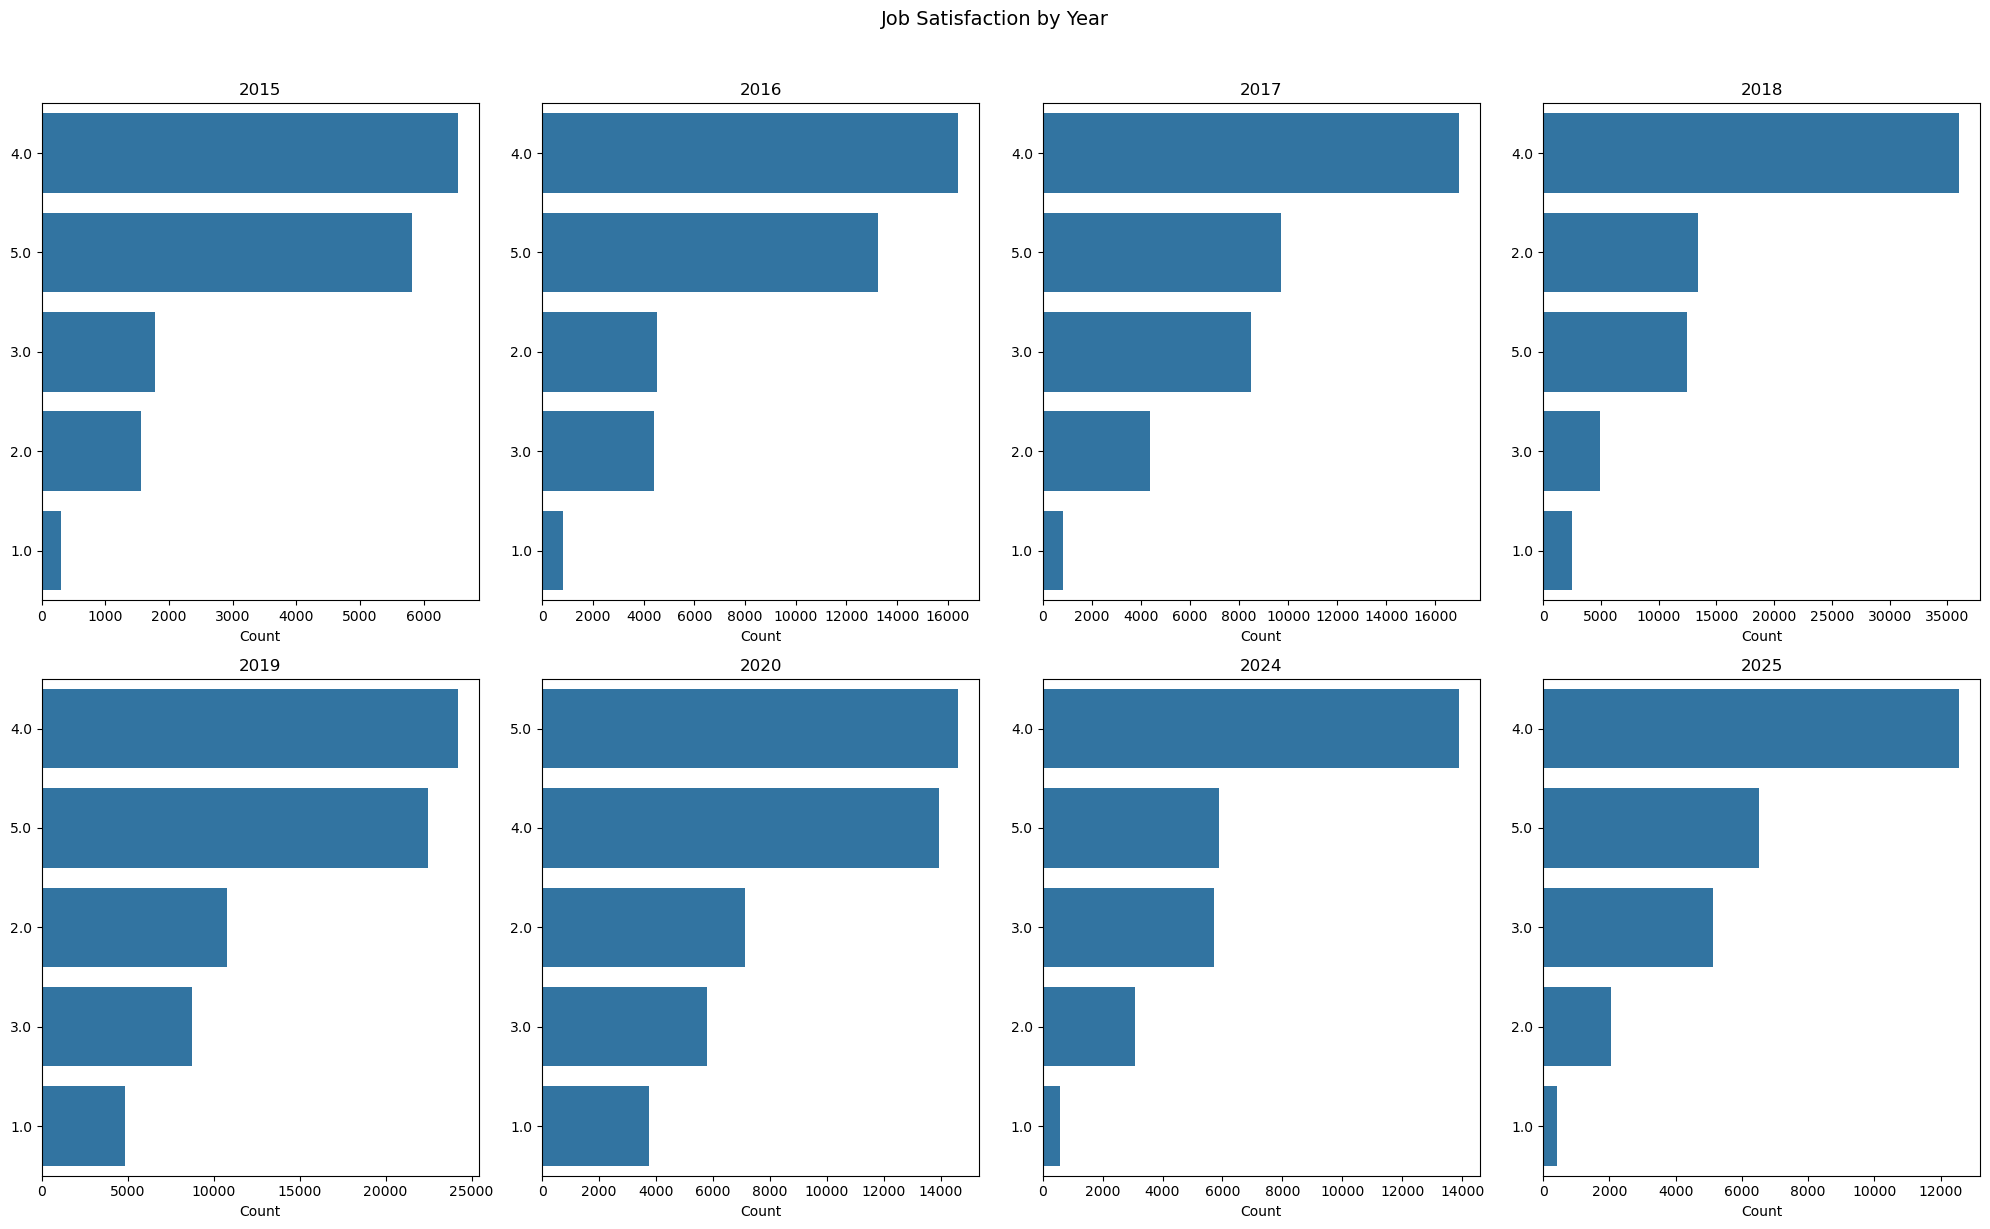

In [105]:
years = sorted(df_model['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model[df_model['survey_year'] == year]
    order = df_year['job_sat_std'].value_counts().index
    sns.countplot(data=df_year, y='job_sat_std', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Job Satisfaction by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [106]:
EDU_MAP = {
    "Primary/elementary school":    "Below secondary",
    "Secondary school":             "Below secondary",
    "No formal education / other":  "Below secondary",
    "Other / ungrouped":            "Below secondary",
    "Some college/university":      "Some college",
    "Associate degree":             "Some college",
    "Bachelor's degree":            "Bachelor's",
    "Master's degree":              "Postgraduate",
    "Professional degree":          "Postgraduate",
    "Doctoral degree":              "Postgraduate",
}

df_model["education_clean"] = (
    df_model["education_clean"]
    .map(EDU_MAP)
    .fillna("Unknown")
)

print(df_model["education_clean"].value_counts())
print()
print(df_model.groupby("survey_year")["education_clean"].value_counts().unstack(fill_value=0))


education_clean
Bachelor's         138838
Postgraduate        90191
Below secondary     57414
Some college        43928
Unknown              6688
Name: count, dtype: int64

education_clean  Bachelor's  Below secondary  Postgraduate  Some college  \
survey_year                                                                
2015                   4956             6248          2172          1363   
2016                      0            32866          3322          1322   
2017                  18902             3046         11990          6086   
2018                  33459             4988         19467         10305   
2019                  34301             4254         20955         10225   
2020                  21988             2352         13593          6439   
2024                  13126             1942          9815          4243   
2025                  12106             1718          8877          3945   

education_clean  Unknown  
survey_year               
2015        

Continuous / count feature audit:


,feature,dtype,missing_pct,min,p01,p05,median,p95,p99,max,skew,iqr_lower_bound,iqr_upper_bound,pct_below_iqr_bound,pct_above_iqr_bound
5,work_exp_clean,float64,83.70,0.000000,1.000000,2.0000,10.000000,30.000000,41.000000,50.000000,1.104,-14.500000,37.50000,0.0,0.34
4,log_comp_real_2025,float64,32.33,6.907755,8.031719,8.8109,11.162517,12.354618,13.776324,14.064006,-0.521,8.537074,13.55911,1.6,0.94
2,database_count,float64,28.07,1.000000,1.000000,1.0000,2.000000,6.000000,9.000000,35.000000,2.044,-3.500000,8.50000,0.0,0.77
3,platform_count,float64,25.10,1.000000,1.000000,1.0000,2.000000,6.000000,9.000000,27.000000,1.624,-3.500000,8.50000,0.0,0.89
1,language_count,float64,7.64,1.000000,1.000000,1.0000,4.000000,10.000000,13.000000,47.000000,1.576,-1.500000,10.50000,0.0,3.06
6,experience_proxy_years,float64,7.08,0.000000,0.500000,1.0000,6.000000,23.000000,34.000000,50.000000,1.623,-9.000000,23.00000,0.0,4.63
7,professional_experience_years,float64,7.08,0.000000,0.500000,1.0000,6.000000,23.000000,34.000000,50.000000,1.623,-9.000000,23.00000,0.0,4.63
0,years_code_clean,float64,0.59,0.500000,1.000000,2.0000,10.000000,30.000000,40.000000,50.000000,1.341,-9.000000,31.00000,0.0,3.69
8,role_family_count,int64,0.00,0.000000,0.000000,1.0000,1.000000,6.000000,8.000000,14.000000,1.839,-2.000000,6.00000,0.0,3.22



Binary indicator feature audit:


,feature,dtype,missing_pct,mean,sum,value_counts
0,is_employed,bool,0.0,0.9912,334081,"{True: 334081, False: 2978}"
1,is_professional,bool,0.0,0.9335,314634,"{True: 314634, False: 22425}"
7,role_full_stack,int64,0.0,0.4841,163175,"{0: 173884, 1: 163175}"
2,role_back_end,int64,0.0,0.3598,121287,"{0: 215772, 1: 121287}"
6,role_front_end,int64,0.0,0.2182,73552,"{0: 263507, 1: 73552}"
3,role_data_ml,int64,0.0,0.1798,60595,"{0: 276464, 1: 60595}"
4,role_desktop_enterprise,int64,0.0,0.1714,57786,"{0: 279273, 1: 57786}"
9,role_mobile,int64,0.0,0.1487,50104,"{0: 286955, 1: 50104}"
5,role_devops_cloud,int64,0.0,0.1398,47115,"{0: 289944, 1: 47115}"
12,role_student_academic,int64,0.0,0.0752,25361,"{0: 311698, 1: 25361}"


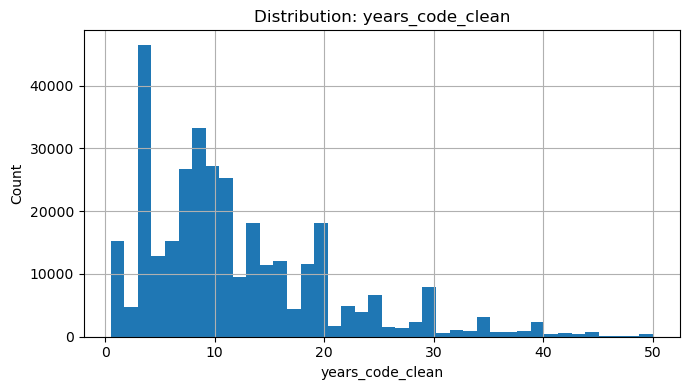

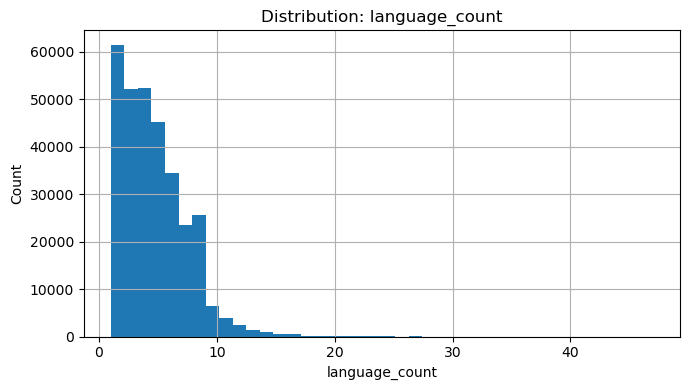

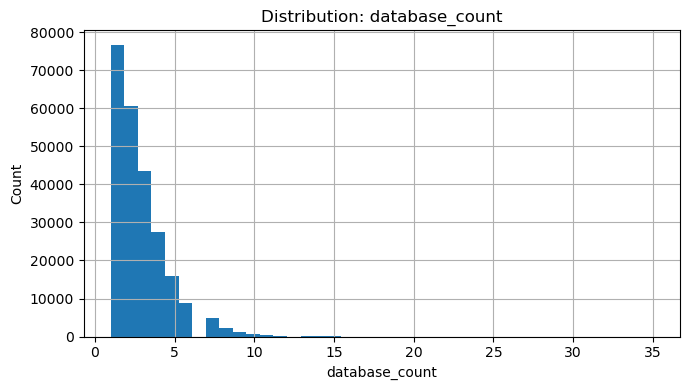

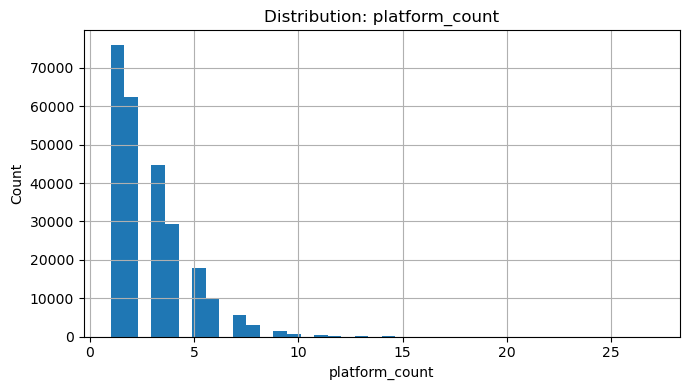

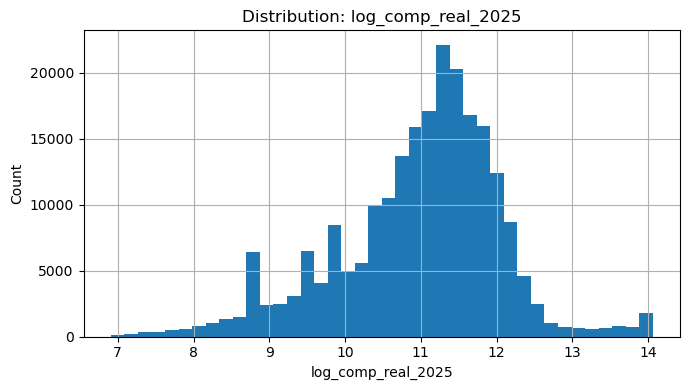

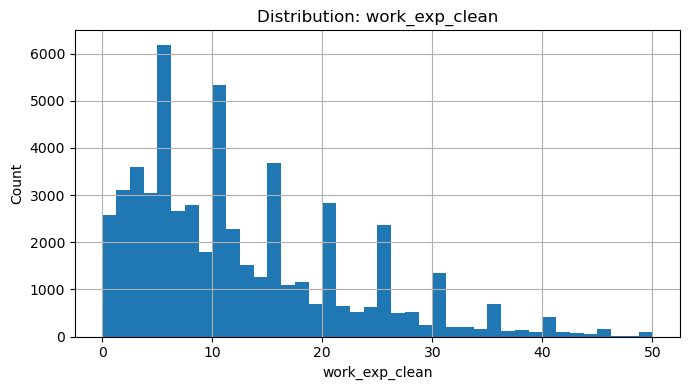

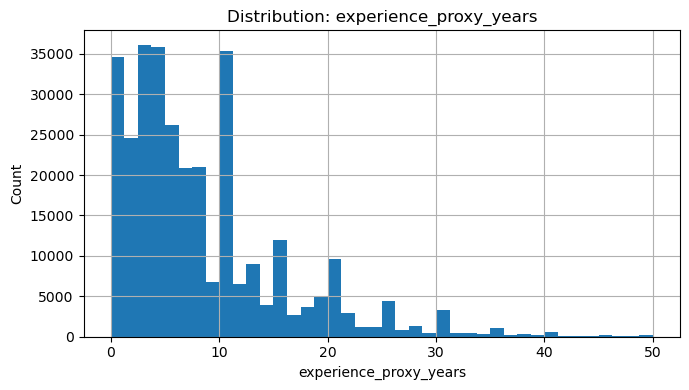

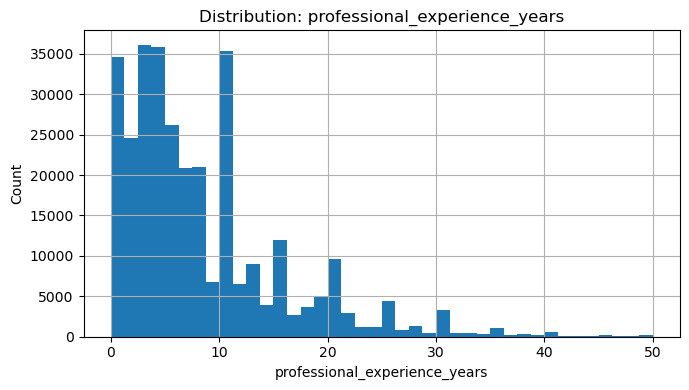

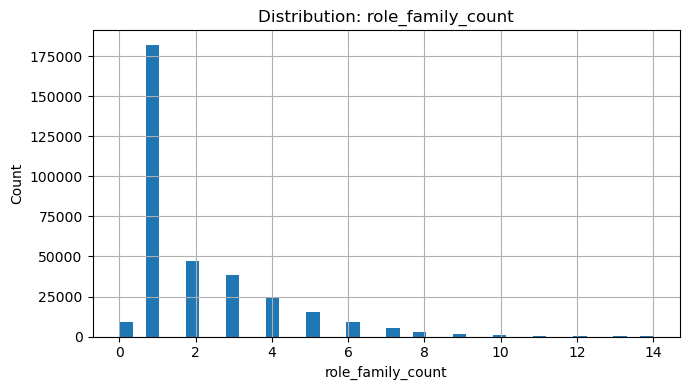

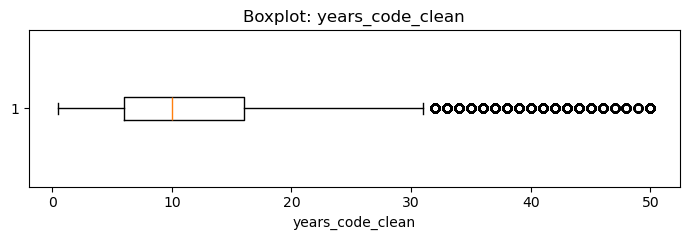

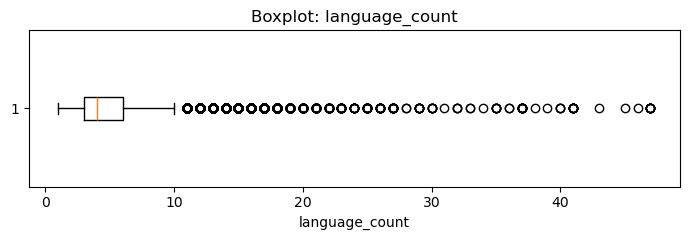

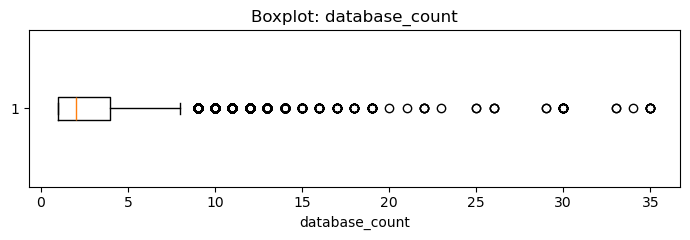

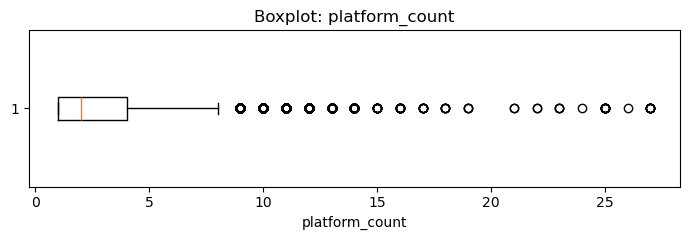

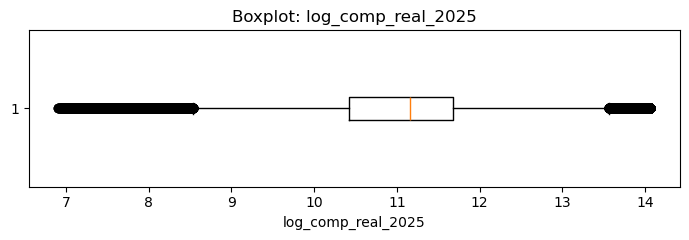

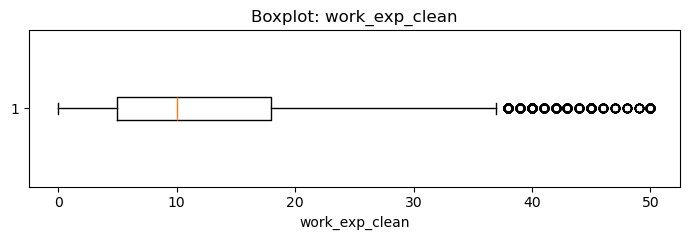

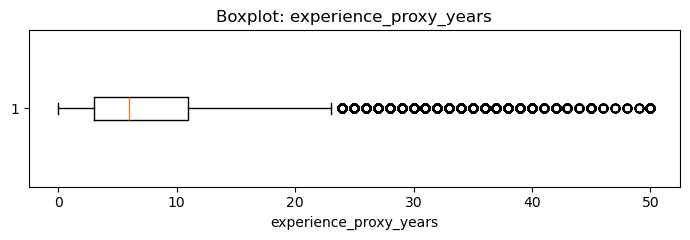

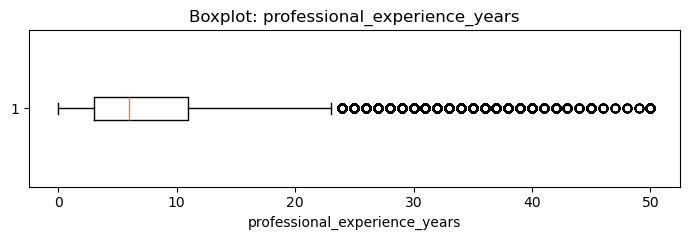

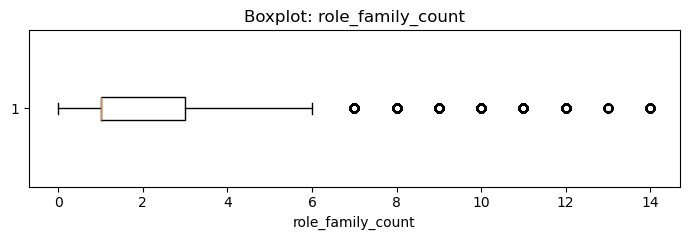

In [107]:
#checking numeric cols
cont_features = [
    'years_code_clean',
    'language_count',
    'database_count',
    'platform_count',
    'log_comp_real_2025',
    'work_exp_clean',
    'experience_proxy_years',
    'professional_experience_years',
    'role_family_count'
]
cont_features = [c for c in cont_features if c in df_model.columns]

binary_features = [
    'is_employed',
    'is_professional',
    'role_back_end',
    'role_data_ml',
    'role_desktop_enterprise',
    'role_devops_cloud',
    'role_front_end',
    'role_full_stack',
    'role_management',
    'role_mobile',
    'role_other',
    'role_qa_testing',
    'role_student_academic'
]
binary_features = [c for c in binary_features if c in df_model.columns]

audit_rows = []

for col in cont_features:
    s = pd.to_numeric(df_model[col], errors='coerce')

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr

    audit_rows.append({
        'feature': col,
        'dtype': str(df_model[col].dtype),
        'missing_pct': round(s.isna().mean() * 100, 2),
        'min': s.min(),
        'p01': s.quantile(0.01),
        'p05': s.quantile(0.05),
        'median': s.median(),
        'p95': s.quantile(0.95),
        'p99': s.quantile(0.99),
        'max': s.max(),
        'skew': round(s.skew(), 3),
        'iqr_lower_bound': lower_iqr,
        'iqr_upper_bound': upper_iqr,
        'pct_below_iqr_bound': round((s < lower_iqr).mean() * 100, 2),
        'pct_above_iqr_bound': round((s > upper_iqr).mean() * 100, 2),
    })

audit_df = pd.DataFrame(audit_rows).sort_values(['missing_pct', 'skew'], ascending=[False, False])

print("Continuous / count feature audit:")
display(audit_df)

binary_rows = []

for col in binary_features:
    s = df_model[col]
    if s.dtype == bool:
        s_num = s.astype(int)
    else:
        s_num = pd.to_numeric(s, errors='coerce')

    binary_rows.append({
        'feature': col,
        'dtype': str(df_model[col].dtype),
        'missing_pct': round(s_num.isna().mean() * 100, 2),
        'mean': round(s_num.mean(), 4),   
        'sum': s_num.sum(),
        'value_counts': s.value_counts(dropna=False).to_dict()
    })

binary_df = pd.DataFrame(binary_rows).sort_values('mean', ascending=False)

print("\nBinary indicator feature audit:")
display(binary_df)

for col in cont_features:
    plt.figure(figsize=(7, 4))
    pd.to_numeric(df_model[col], errors='coerce').dropna().hist(bins=40)
    plt.title(f'Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for col in cont_features:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(pd.to_numeric(df_model[col], errors='coerce').dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Clip summary:


,feature,lower_clip,upper_clip,before_min,before_max,after_min,after_max
0,years_code_clean,1.000000,40.000000,0.500000,50.000000,1.000000,40.000000
1,language_count,1.000000,13.000000,1.000000,47.000000,1.000000,13.000000
2,database_count,1.000000,9.000000,1.000000,35.000000,1.000000,9.000000
3,platform_count,1.000000,9.000000,1.000000,27.000000,1.000000,9.000000
4,log_comp_real_2025,8.031719,13.776324,6.907755,14.064006,8.031719,13.776324
5,work_exp_clean,1.000000,41.000000,0.000000,50.000000,1.000000,41.000000
6,experience_proxy_years,0.500000,34.000000,0.000000,50.000000,0.500000,34.000000
7,professional_experience_years,0.500000,34.000000,0.000000,50.000000,0.500000,34.000000
8,role_family_count,0.000000,8.000000,0.000000,14.000000,0.000000,8.000000


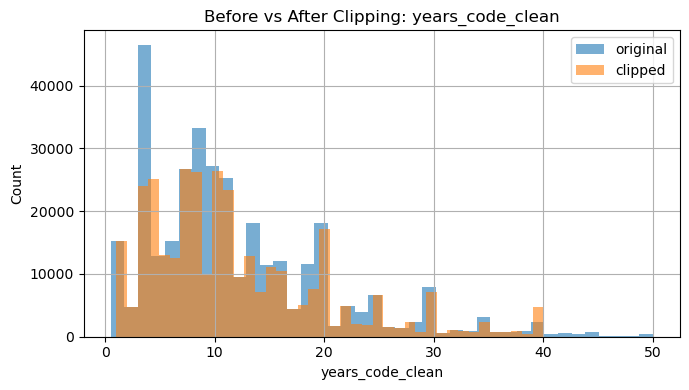

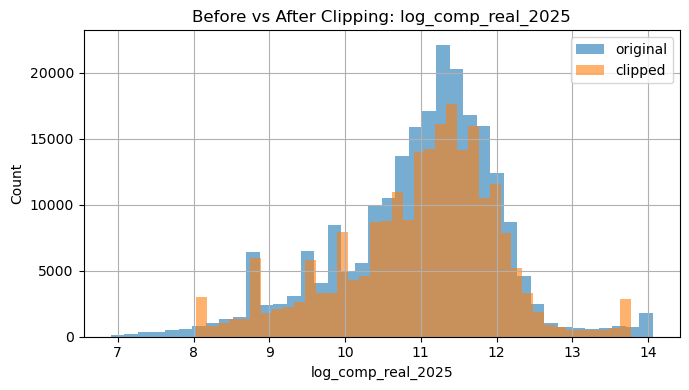

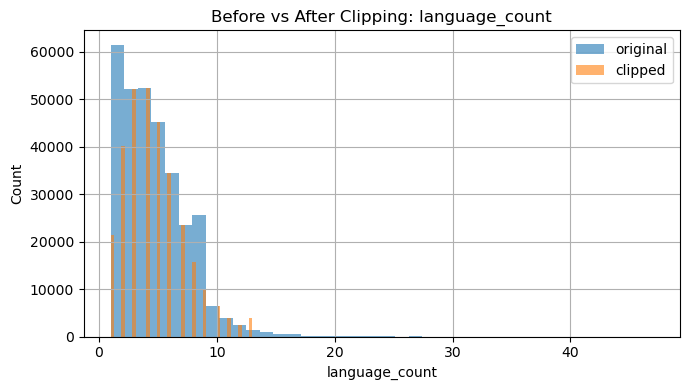

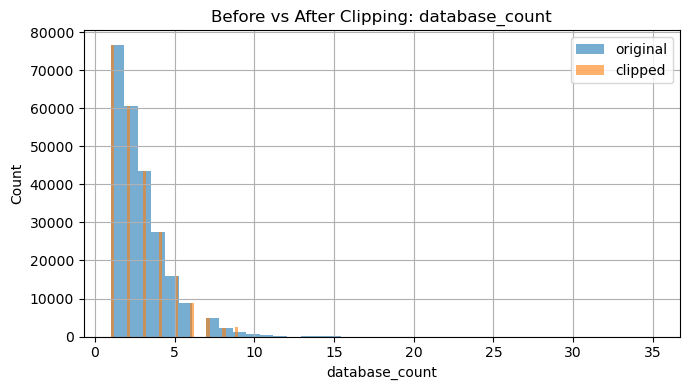

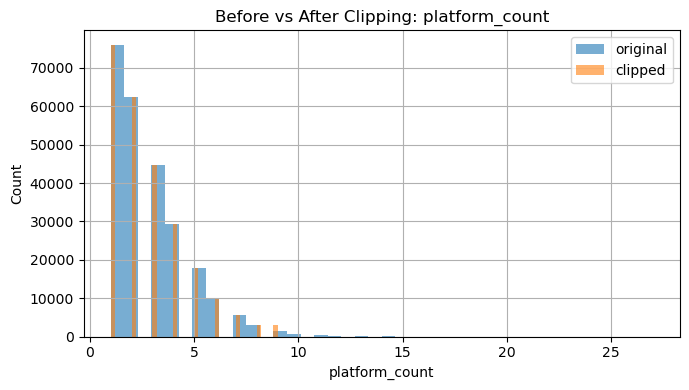

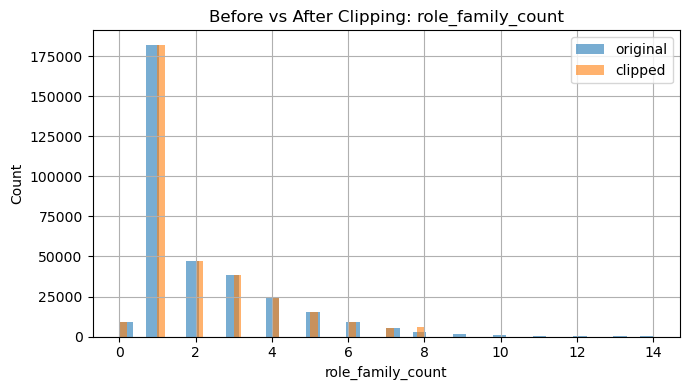

New binned columns added:
['years_code_bin', 'comp_bin', 'language_count_bin', 'database_count_bin', 'platform_count_bin', 'role_family_count_bin']


In [108]:
#clipping outliers

df_model_improved = df_model.copy()
for col in cont_features:
    df_model_improved[col] = pd.to_numeric(df_model_improved[col], errors='coerce')
for col in binary_features:
    if col in df_model_improved.columns and df_model_improved[col].dtype == bool:
        df_model_improved[col] = df_model_improved[col].astype(int)
clip_summary = []

for col in cont_features:
    lower = df_model_improved[col].quantile(0.01)
    upper = df_model_improved[col].quantile(0.99)

    before_min = df_model_improved[col].min()
    before_max = df_model_improved[col].max()

    df_model_improved[col] = df_model_improved[col].clip(lower=lower, upper=upper)

    after_min = df_model_improved[col].min()
    after_max = df_model_improved[col].max()

    clip_summary.append({
        'feature': col,
        'lower_clip': lower,
        'upper_clip': upper,
        'before_min': before_min,
        'before_max': before_max,
        'after_min': after_min,
        'after_max': after_max
    })

clip_summary_df = pd.DataFrame(clip_summary)
print("Clip summary:")
display(clip_summary_df)

if 'years_code_clean' in df_model_improved.columns:
    df_model_improved['years_code_bin'] = pd.cut(
        df_model_improved['years_code_clean'],
        bins=[-np.inf, 2, 5, 10, 15, 20, np.inf],
        labels=['0-2', '3-5', '6-10', '11-15', '16-20', '21+']
    ).astype('category')

if 'log_comp_real_2025' in df_model_improved.columns:
    df_model_improved['comp_bin'] = pd.qcut(
        df_model_improved['log_comp_real_2025'],
        q=5,
        duplicates='drop'
    ).astype('category')

if 'language_count' in df_model_improved.columns:
    df_model_improved['language_count_bin'] = pd.cut(
        df_model_improved['language_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'database_count' in df_model_improved.columns:
    df_model_improved['database_count_bin'] = pd.cut(
        df_model_improved['database_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'platform_count' in df_model_improved.columns:
    df_model_improved['platform_count_bin'] = pd.cut(
        df_model_improved['platform_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'role_family_count' in df_model_improved.columns:
    df_model_improved['role_family_count_bin'] = pd.cut(
        df_model_improved['role_family_count'],
        bins=[-np.inf, 1, 2, 3, 4, np.inf],
        labels=['1', '2', '3', '4', '5+']
    ).astype('category')

#before vs after
for col in ['years_code_clean', 'log_comp_real_2025', 'language_count', 'database_count', 'platform_count', 'role_family_count']:
    if col not in df_model.columns or col not in df_model_improved.columns: continue
    fig, ax = plt.subplots(figsize=(7, 4))
    pd.to_numeric(df_model[col], errors='coerce').dropna().hist(bins=40, alpha=0.6, label='original', ax=ax)
    pd.to_numeric(df_model_improved[col], errors='coerce').dropna().hist(bins=40, alpha=0.6, label='clipped', ax=ax)
    ax.set_title(f'Before vs After Clipping: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

print("New binned columns added:")
print([c for c in df_model_improved.columns if c.endswith('_bin')])

In [109]:
df_model_improved.columns

Index(['survey_year', 'region', 'age_group', 'employment_addl',
       'employment_primary', 'employment_group', 'is_employed',
       'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed',
       'is_independent', 'is_student_status', 'is_retired_status',
       'is_not_employed', 'is_professional', 'education_clean',
       'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry',
       'industry_clean', 'remote_group', 'language_count', 'database_count',
       'platform_count', 'years_code_clean', 'years_code_pro',
       'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_years',
       'experience_proxy_source', 'professional_experience_years',
       'log_comp_real_2025', 'role_family_count', 'role_advocacy_dx',
       'role_architecture', 'role_back_end', 'role_data_ml', 'role_design_ux',
       'role_desktop_enterprise', 'role_devops_cloud',
       'role_embedded_hardware', 'role_front_end', 'role_full_stack',
       'role_game_graphics', 'r

In [110]:
dupes = df_model_improved.columns[df_model_improved.columns.duplicated()]
print("Duplicate columns:", dupes.tolist())

Duplicate columns: []


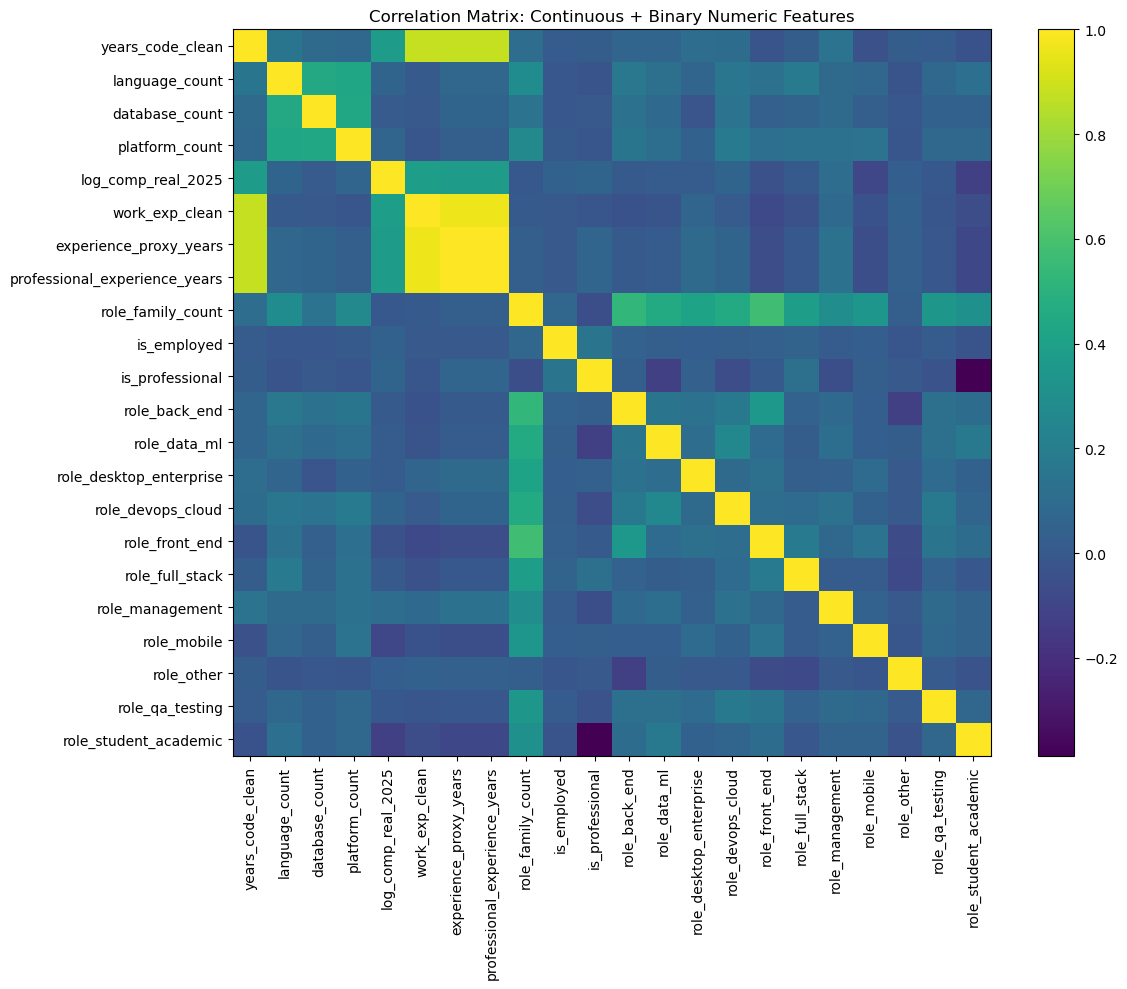

Strong correlation pairs (|corr| >= 0.70):


,feature_1,feature_2,corr
5,experience_proxy_years,professional_experience_years,1.000
3,work_exp_clean,experience_proxy_years,0.964
4,work_exp_clean,professional_experience_years,0.964
0,years_code_clean,work_exp_clean,0.880
1,years_code_clean,experience_proxy_years,0.879
2,years_code_clean,professional_experience_years,0.879


In [111]:
corr_cols = cont_features + binary_features
corr_cols = [c for c in corr_cols if c in df_model_improved.columns]
corr_df = df_model_improved[corr_cols].copy()

if corr_df.columns.duplicated().any():
    print("Dropping duplicate column names in corr_df:")
    print(corr_df.columns[corr_df.columns.duplicated()].tolist())
    corr_df = corr_df.loc[:, ~corr_df.columns.duplicated()].copy()

for col in corr_df.columns:
    series = corr_df[col]
    
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    
    if series.dtype == bool:
        corr_df[col] = series.astype(int)
    else:
        corr_df[col] = pd.to_numeric(series, errors='coerce')

corr = corr_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix: Continuous + Binary Numeric Features')
plt.tight_layout()
plt.show()

strong_pairs = []
for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if j <= i:
            continue
        val = corr.loc[col1, col2]
        if pd.notna(val) and abs(val) >= 0.70:
            strong_pairs.append((col1, col2, round(val, 3)))

strong_pairs_df = pd.DataFrame(strong_pairs, columns=['feature_1', 'feature_2', 'corr'])

print("Strong correlation pairs (|corr| >= 0.70):")
if strong_pairs_df.empty:
    print("None found")
else:
    display(strong_pairs_df.sort_values('corr', ascending=False))

In [112]:
redundant_cols = ['experience_proxy_years','work_exp_clean']

if redundant_cols:
    print("Dropping redundant columns:", redundant_cols)
    df_model_improved = df_model_improved.drop(columns=redundant_cols)
    cont_features = [c for c in cont_features if c in df_model_improved.columns]

Dropping redundant columns: ['experience_proxy_years', 'work_exp_clean']


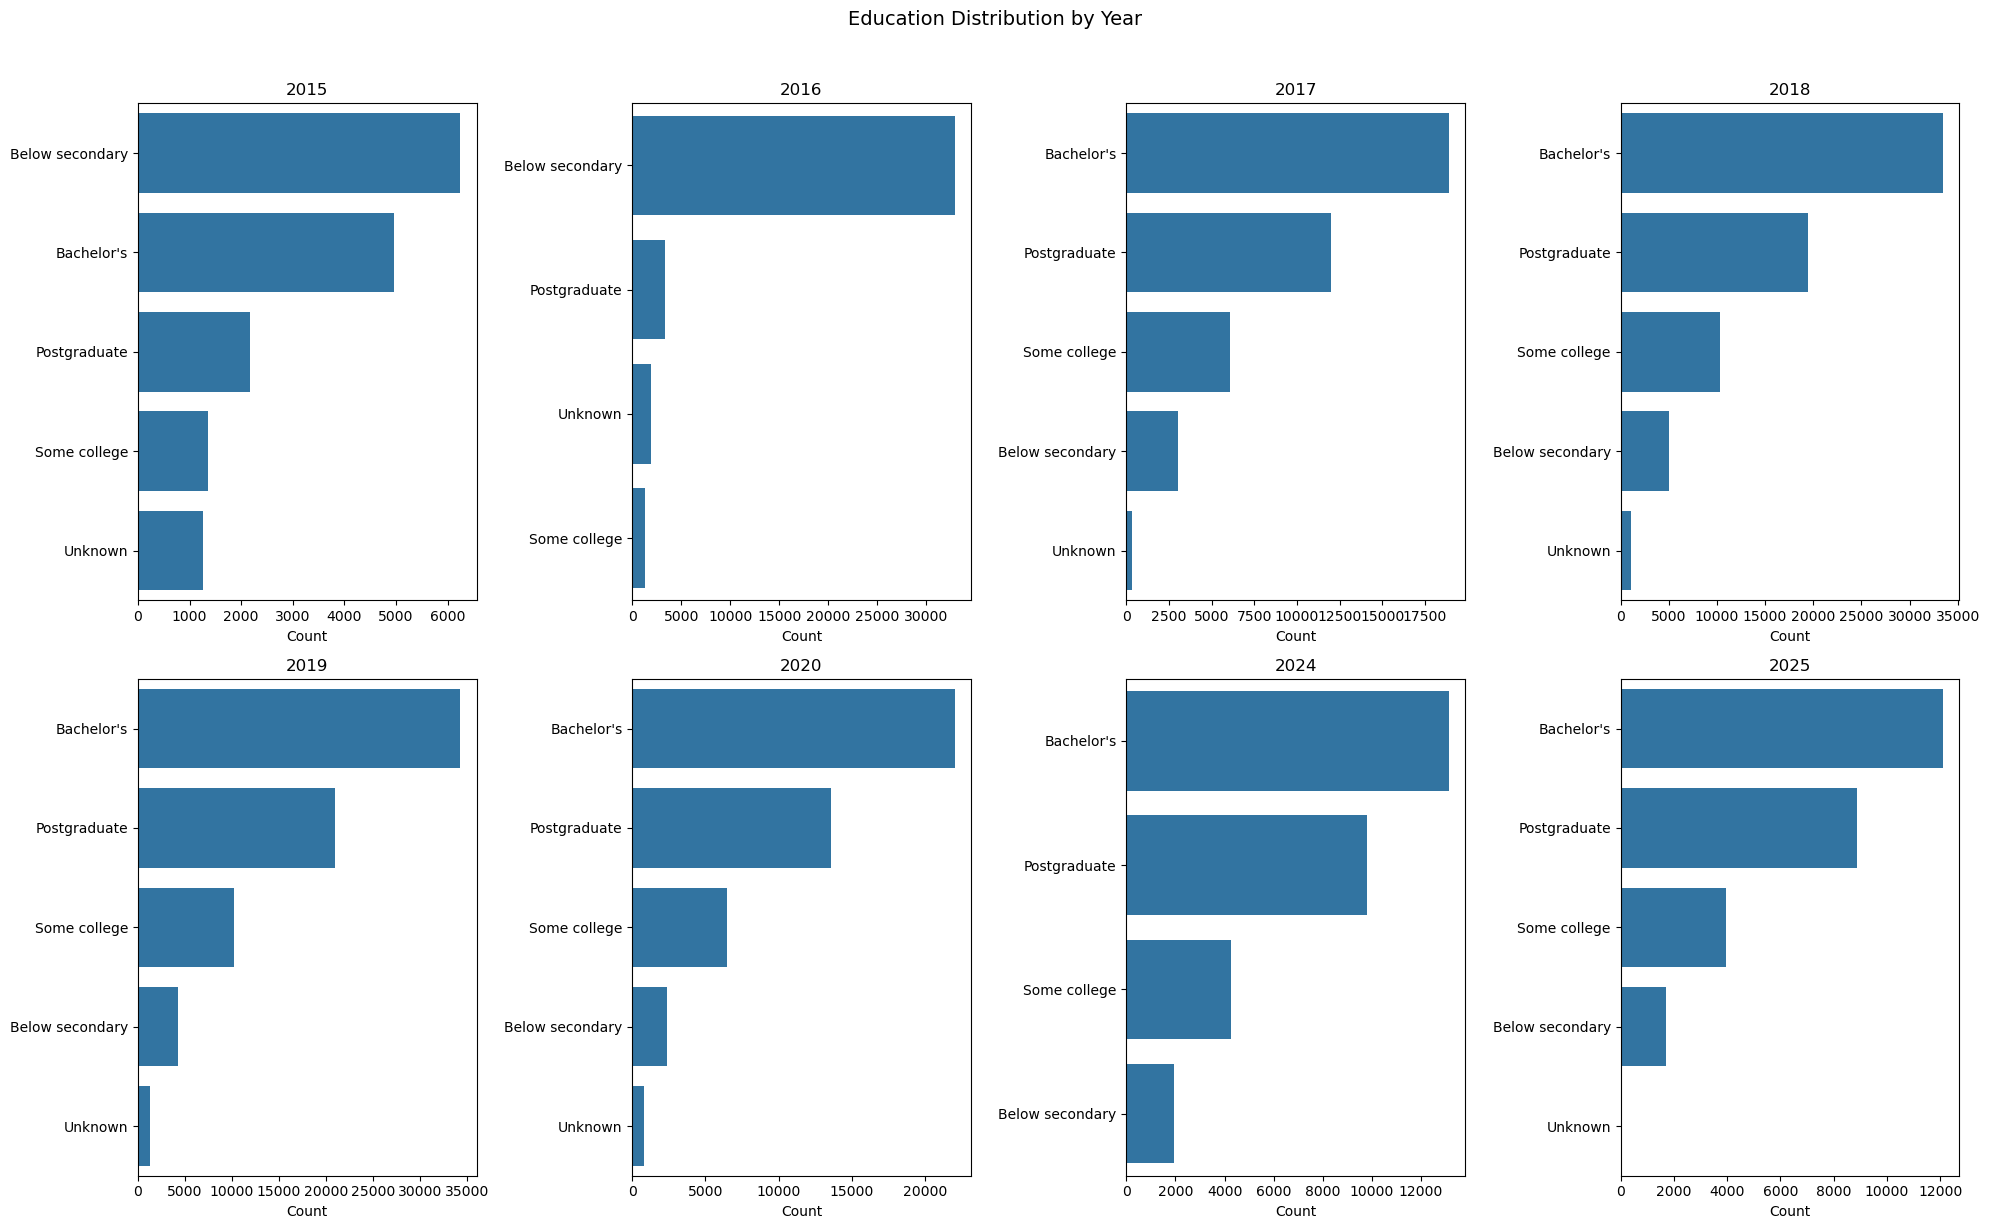

In [113]:
years = sorted(df_model_improved['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model_improved[df_model_improved['survey_year'] == year]
    order = df_year['education_clean'].value_counts().index
    sns.countplot(data=df_year, y='education_clean', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Education Distribution by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 490
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 27
[LightGBM] [Info] Start training from score 3.732617
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 1.20993
[200]	valid_0's l2: 1.20819
Early stopping, best iteration is:
[245]	valid_0's l2: 1.20785
RMSE: 1.099
R2:   0.043
QWK (rounded predictions): 0.081


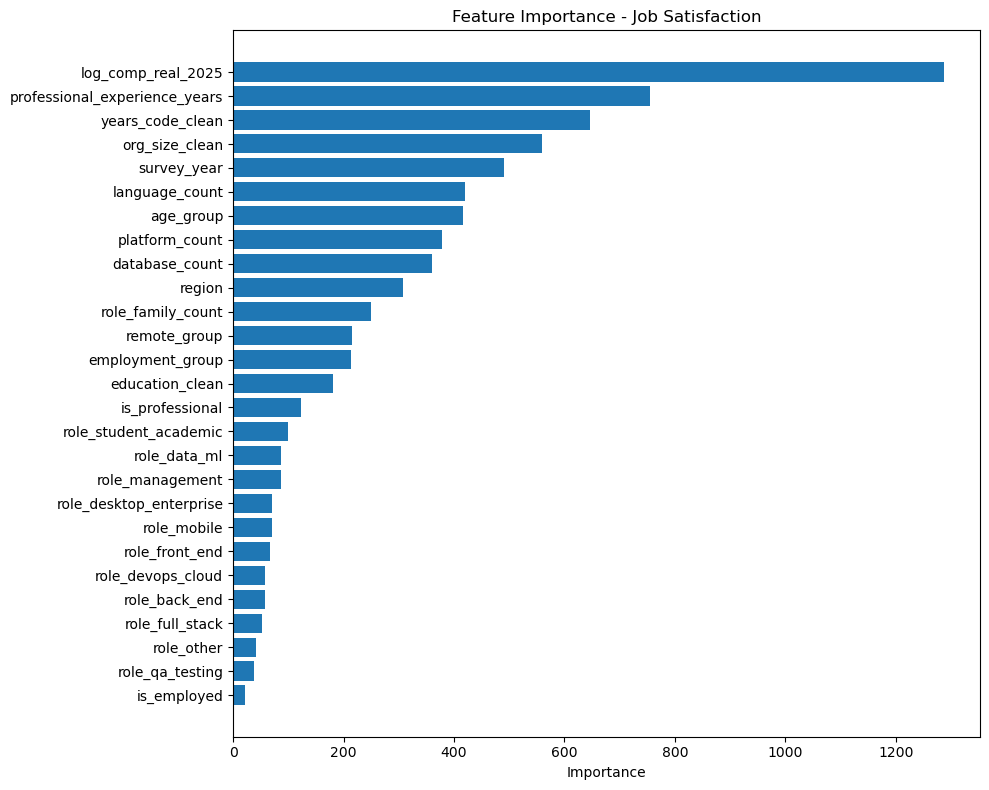

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [114]:
# --- Features ---
cat_features = [
    'survey_year', 'region', 'age_group', 'education_clean',
    'employment_group', 'org_size_clean', 'remote_group'
]
num_features = [
    'is_employed',
    'is_professional',
    'years_code_clean',
    'professional_experience_years',
    'language_count',
    'database_count',
    'platform_count',
    'log_comp_real_2025',
    'role_family_count',
    'role_back_end',
    'role_data_ml',
    'role_desktop_enterprise',
    'role_devops_cloud',
    'role_front_end',
    'role_full_stack',
    'role_management',
    'role_mobile',
    'role_other',
    'role_qa_testing',
    'role_student_academic'
]
num_features = [c for c in num_features if c in df_model_improved.columns]
features = cat_features + num_features
target = 'job_sat_std'

X = df_model_improved[features].copy()
y = df_model_improved[target]

# Convert categoricals for LightGBM
for col in cat_features:
    X[col] = X[col].astype('category')

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.astype(int)
)

# --- Train ---
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model.predict(X_test)
y_pred_rounded = np.clip(np.round(y_pred), 1, 5).astype(int)
y_test_int = y_test.astype(int)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R2:   {r2_score(y_test, y_pred):.3f}")
qwk = cohen_kappa_score(y_test_int, y_pred_rounded, weights='quadratic')
print(f"QWK (rounded predictions): {qwk:.3f}")

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save metrics for comparison
from sklearn.metrics import classification_report as _cr
_rep = _cr(y_test_int, y_pred_rounded, output_dict=True)
results_reg = {
    'rmse':        round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 3),
    'r2':          round(float(r2_score(y_test, y_pred)), 3),
    'qwk':         round(float(cohen_kappa_score(y_test_int, y_pred_rounded, weights='quadratic')), 3),
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
}


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 490
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 27
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.53782
[200]	valid_0's multi_logloss: 1.53388
[300]	valid_0's multi_logloss: 1.5312
[400]	valid_0's multi_logloss: 1.52902
[500]	valid_0's multi_logloss: 1.52723
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 1.52723
                   precision    rec

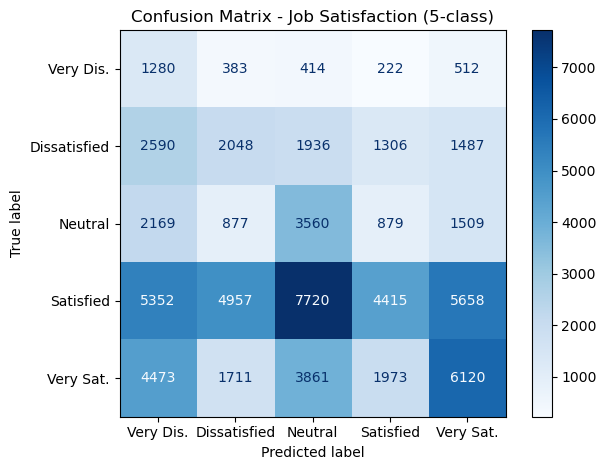

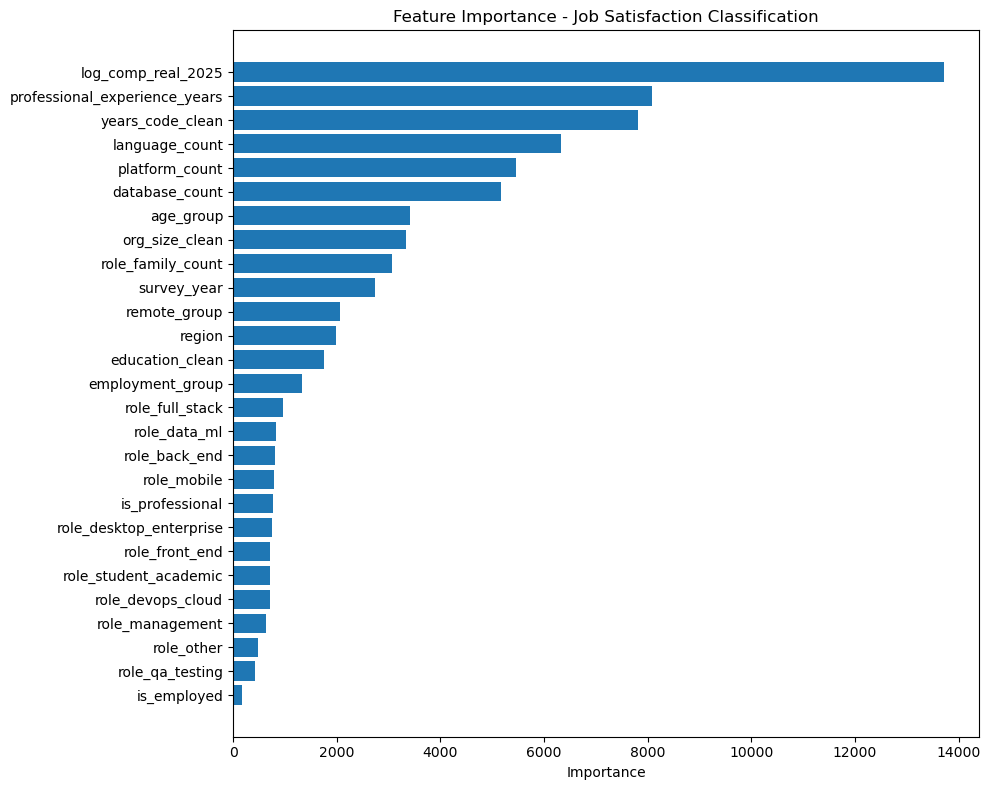

In [115]:
# --- Classification model (5-class ordinal: 1=Very Dissatisfied ... 5=Very Satisfied) ---
SAT_LABELS = [1, 2, 3, 4, 5]

X = df_model_improved[features].copy()
y = df_model_improved['job_sat_std'].astype(int)

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.astype(int)
)

model_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_clf.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model_clf.predict(X_test)
print(classification_report(y_test, y_pred, labels=SAT_LABELS,
      target_names=['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic', labels=SAT_LABELS)
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred, labels=SAT_LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=['Very Dis.', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Sat.'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Job Satisfaction (5-class)')
plt.tight_layout()
plt.show()

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model_clf.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save metrics for comparison
from sklearn.metrics import classification_report as _cr
_rep = _cr(y_test, y_pred, output_dict=True)
results_clf = {
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
    'qwk':         round(float(cohen_kappa_score(y_test, y_pred, weights='quadratic', labels=SAT_LABELS)), 3),
    'baseline':    round(float(pd.Series(y_test).value_counts(normalize=True).max()), 3),
}


In [116]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
# --- Binary satisfaction ---
df_model_improved['sat_binary'] = (df_model_improved['job_sat_std'] >= 4).astype(int)
print(df_model_improved['sat_binary'].value_counts())
print(df_model_improved['sat_binary'].value_counts(normalize=True).mul(100).round(1))

# --- Train/test split ---
X = df_model_improved[features].copy()
y = df_model_improved['sat_binary']

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.astype(int)
)

models_dict = {
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'XGB': XGBClassifier(enable_categorical=True, random_state=42)
}

score_dict = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_dict.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_weighted'
    )
    score_dict[name] = scores.mean()

print(score_dict)

sat_binary
1    231198
0    105861
Name: count, dtype: int64
sat_binary
1    68.6
0    31.4
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 147966, number of negative: 67751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 490
[LightGBM] [Info] Number of data points in the train set: 215717, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.685926 -> initscore=0.781143
[LightGBM] [Info] Start training from score 0.781143
[LightGBM] [Info] Number of positive: 147966, number of negative: 67751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

In [117]:
from sklearn.metrics import f1_score

def prep_catboost_cats(df, cat_features):
    df = df.copy()
    for col in cat_features:
        if col in df.columns: df[col] = df[col].astype(object).where(df[col].notna(), 'Missing').astype(str)
    return df

cat_features_idx = [X_train.columns.get_loc(col) for col in cat_features if col in X_train.columns]

cat_scores = []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr = prep_catboost_cats(X_train.iloc[train_idx], cat_features)
    X_val = prep_catboost_cats(X_train.iloc[val_idx], cat_features)
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = CatBoostClassifier(
        verbose=0,
        random_state=42
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features_idx
    )

    preds = model.predict(X_val).ravel()
    cat_scores.append(f1_score(y_val, preds, average='weighted'))

print("CatBoost mean CV weighted F1:", np.mean(cat_scores))

CatBoost mean CV weighted F1: 0.5890679852816298


In [118]:
import optuna
RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 40   
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

X_train_opt = X_train.copy()
for col in cat_features:
    if col in X_train_opt.columns:
        X_train_opt[col] = X_train_opt[col].astype('category')

n_classes = y_train.nunique()

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 128, 512),
        'random_state': RANDOM_STATE,
        'tree_method': 'hist',
        'enable_categorical': True,
        'n_estimators': 1000,
        'n_jobs': -1,
        'objective': 'multi:softmax' if n_classes > 2 else 'binary:logistic',
        'eval_metric': 'mlogloss' if n_classes > 2 else 'logloss',
        **({'num_class': n_classes} if n_classes > 2 else {}) 
    }

    fold_scores = []
    for train_idx, val_idx in cv.split(X_train_opt, y_train):
        X_tr  = X_train_opt.iloc[train_idx].copy()
        X_val = X_train_opt.iloc[val_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50, 
            verbose=False
        )

        preds = model.predict(X_val)
        score = f1_score(y_val, preds, average='weighted')
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Best trial score:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-04-11 21:33:08,004] A new study created in memory with name: no-name-c36effd8-5335-4b4c-9566-04a8e0272196


  0%|          | 0/40 [00:00<?, ?it/s]

[W 2026-04-11 21:33:08,067] Trial 0 failed with parameters: {'learning_rate': 0.01106190425027052, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.7742523318901556, 'colsample_bytree': 0.9972676506545319, 'gamma': 2.5129636292647124, 'reg_alpha': 2.8286739878508285, 'reg_lambda': 0.07021065282060573, 'max_bin': 246} because of the following error: TypeError("XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'").
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/9b/jyss1xc93y77hbkw1rh8mlmm0000gn/T/ipykernel_36049/2159655009.py", line 43, in objective
    model.fit(
    ~~~~~~~~~^
        X_tr, y_tr,
        ^^^^^^^^^^^
    ...<2 lines>...
        verbose=False
        ^^^^^^^^^^^^^
    )
    ^
  File "/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
Type

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [ ]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in cat_features:
    if col in X_train_xgb.columns: X_train_xgb[col] = X_train_xgb[col].astype('category')
    if col in X_test_xgb.columns: X_test_xgb[col] = X_test_xgb[col].astype('category')

best_params = study.best_params.copy()

final_params = {
    **best_params,
    'random_state': 42,
    'tree_method': 'hist',
    'enable_categorical': True,
    'n_jobs': -1,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss'
}

model_bin_xgb = XGBClassifier(**final_params)

model_bin_xgb.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=False,
    early_stopping_rounds=50
)

print("Final tuned XGBoost model fitted.")
print(final_params)
print(f"Best iteration: {model_bin_xgb.best_iteration}")
y_pred = model_bin_xgb.predict(X_test_xgb)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Satisfied', 'Satisfied'],
    zero_division=0
))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Satisfied', 'Satisfied'])
disp.plot()
plt.title('Confusion Matrix - Job Satisfaction (Binary, Tuned XGBoost)')
plt.tight_layout()
plt.show()

importance = (
    pd.DataFrame({
        'feature': features,
        'importance': model_bin_xgb.feature_importances_
    })
    .sort_values('importance', ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction (Binary, Tuned XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report as _cr

_rep = _cr(y_test, y_pred, output_dict=True, zero_division=0)

results_bin_xgb = {
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
    'qwk':         round(float(cohen_kappa_score(y_test, y_pred, weights='quadratic')), 3),
    'baseline':    round(float(pd.Series(y_test).value_counts(normalize=True).max()), 3),
}

In [121]:
comparison = pd.DataFrame([
    {
        'Model':       'Regression (1-5)',
        'Target':      '1-5 continuous',
        'Accuracy':    results_reg['accuracy'],
        'Macro F1':    results_reg['macro_f1'],
        'Weighted F1': results_reg['weighted_f1'],
        'RMSE':        results_reg['rmse'],
        'R2':          results_reg['r2'],
        'QWK':         results_reg['qwk'],
        'Baseline':    '-',
    },
    {
        'Model':       '5-class Classification',
        'Target':      '1-5 ordinal classes',
        'Accuracy':    results_clf['accuracy'],
        'Macro F1':    results_clf['macro_f1'],
        'Weighted F1': results_clf['weighted_f1'],
        'RMSE':        '-',
        'R2':          '-',
        'QWK':         results_clf['qwk'],
        'Baseline':    results_clf['baseline'],
    },
    {
        'Model':       'Binary Classification (Tuned XGBoost)',
        'Target':      'satisfied / not (>=4)',
        'Accuracy':    results_bin_xgb['accuracy'],
        'Macro F1':    results_bin_xgb['macro_f1'],
        'Weighted F1': results_bin_xgb['weighted_f1'],
        'RMSE':        '-',
        'R2':          '-',
        'QWK':         results_bin_xgb['qwk'],
        'Baseline':    results_bin_xgb['baseline'],
    },
])

display(comparison.set_index('Model'))

NameError: name 'results_bin_xgb' is not defined

In [ ]:
#explainability
import shap
from sklearn.inspection import PartialDependenceDisplay
X_train_explain = X_train.copy()
X_test_explain = X_test.copy()

for col in cat_features:
    if col in X_train_explain.columns: X_train_explain[col] = X_train_explain[col].astype('category')
    if col in X_test_explain.columns: X_test_explain[col] = X_test_explain[col].astype('category')
print("X_train_explain shape:", X_train_explain.shape)
print("X_test_explain shape:", X_test_explain.shape)
print("Number of categorical features:", len([c for c in cat_features if c in X_train_explain.columns]))

In [ ]:
explainer = shap.TreeExplainer(model_bin_xgb)
#limited sample size for now cus running local
sample_n = min(2000, len(X_test_explain))
X_shap = X_test_explain.sample(sample_n, random_state=42)

shap_values = explainer.shap_values(X_shap)
print("Computed SHAP values.")
print("Sample used:", X_shap.shape)
plt.figure(figsize=(15, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot - Tuned XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title("SHAP Feature Importance - Tuned XGBoost")
plt.xlabel('Mean(|SHAP|)')
plt.tight_layout()
plt.show()

In [ ]:
#feat imp:
if isinstance(shap_values, list):shap_abs = np.mean([np.abs(v) for v in shap_values], axis=0)
else:shap_abs = np.abs(shap_values)
mean_abs_shap = shap_abs.mean(axis=0)
shap_importance_df = (pd.DataFrame({'feature': X_shap.columns,'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))
display(shap_importance_df.head(15))
top_shap_features = shap_importance_df['feature'].head(8).tolist()

print("Top SHAP features:")
print(top_shap_features)

In [ ]:
#dep_features = ['log_comp_real_2025', 'years_code_clean', 'professional_experience_years']
X_shap_num = X_shap.copy()
for col in X_shap_num.columns: X_shap_num[col] = pd.to_numeric(X_shap_num[col], errors='coerce')
numeric_cols = X_shap_num.select_dtypes(include=np.number).columns.tolist()
numeric_continuous = [col for col in numeric_cols if X_shap_num[col].nunique(dropna=True) > 10]

dep_features = [f for f in shap_importance_df['feature'] if f in numeric_continuous][:6]

interactions = {
    'log_comp_real_2025': 'professional_experience_years', #pay vs experience relationship
    'professional_experience_years': 'log_comp_real_2025', #experience effect varies by pay
    'years_code_clean': 'log_comp_real_2025', #coding years vs salary
    'language_count': 'professional_experience_years', #skill depth vs experience
    'platform_count': 'professional_experience_years', #tools/platforms vs experience
    'database_count': 'professional_experience_years' #database vs experience
}

for feat in dep_features:
    interaction_feature = interactions.get(feat, None)

    plt.figure(figsize=(7, 5))
    shap.dependence_plot(feat,shap_values, X_shap_num,interaction_index= interaction_feature, show=False)
    title = feat
    if interaction_feature: title += f" (colored by {interaction_feature})"
    plt.title(f"SHAP Dependence Plot - {title}")
    plt.tight_layout()
    plt.show()

In [ ]:
y_prob_sample = model_bin_xgb.predict_proba(X_shap)[:, 1]
y_pred_sample = (y_prob_sample >= 0.5).astype(int)

idx_high_sat = np.argmax(y_prob_sample) #highest predicted satisfied
idx_low_sat = np.argmin(y_prob_sample) #highest predicted not satisfied
idx_borderline = np.argmin(np.abs(y_prob_sample - 0.5)) #closest to threshold 0.5
case_indices = [idx_high_sat, idx_low_sat, idx_borderline]
case_labels = ['highest predicted satisfied', 'highest predicted not satisfied', 'borderline']

for idx, label in zip(case_indices, case_labels):
    print(f"\nWaterfall plot: {label} (sample row index {idx})")
    if isinstance(shap_values, list):
        sv = shap_values[1][idx]
        base_val = explainer.expected_value[1]
    else:
        sv = shap_values[idx]
        base_val = explainer.expected_value

    explanation = shap.Explanation(
        values=sv,
        base_values=base_val,
        data=X_shap.iloc[idx],
        feature_names=X_shap.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"SHAP - {label}")
    plt.tight_layout()
    plt.show()

In [ ]:
#pdp
numeric_cols = X_train_explain.select_dtypes(include=np.number).columns.tolist()
numeric_continuous = [col for col in numeric_cols if X_train_explain[col].nunique() > 10]
pdp_features = [f for f in shap_importance_df['feature'] if f in numeric_continuous][:5]
pdp_features = pdp_features[1:]
print(pdp_features)

for feat in pdp_features:
    pdp_display = PartialDependenceDisplay.from_estimator(model_bin_xgb, X_train_explain, features=[feat],kind='both', subsample=200, random_state=42)
    pdp_display.figure_.set_size_inches(7, 4)
    pdp_display.figure_.suptitle(f"PDP+ICE - {feat}")
    plt.tight_layout()
    plt.show()

# Feature Correlation Heatmap with Target

Compute correlations between features and the binary target (sat_binary)

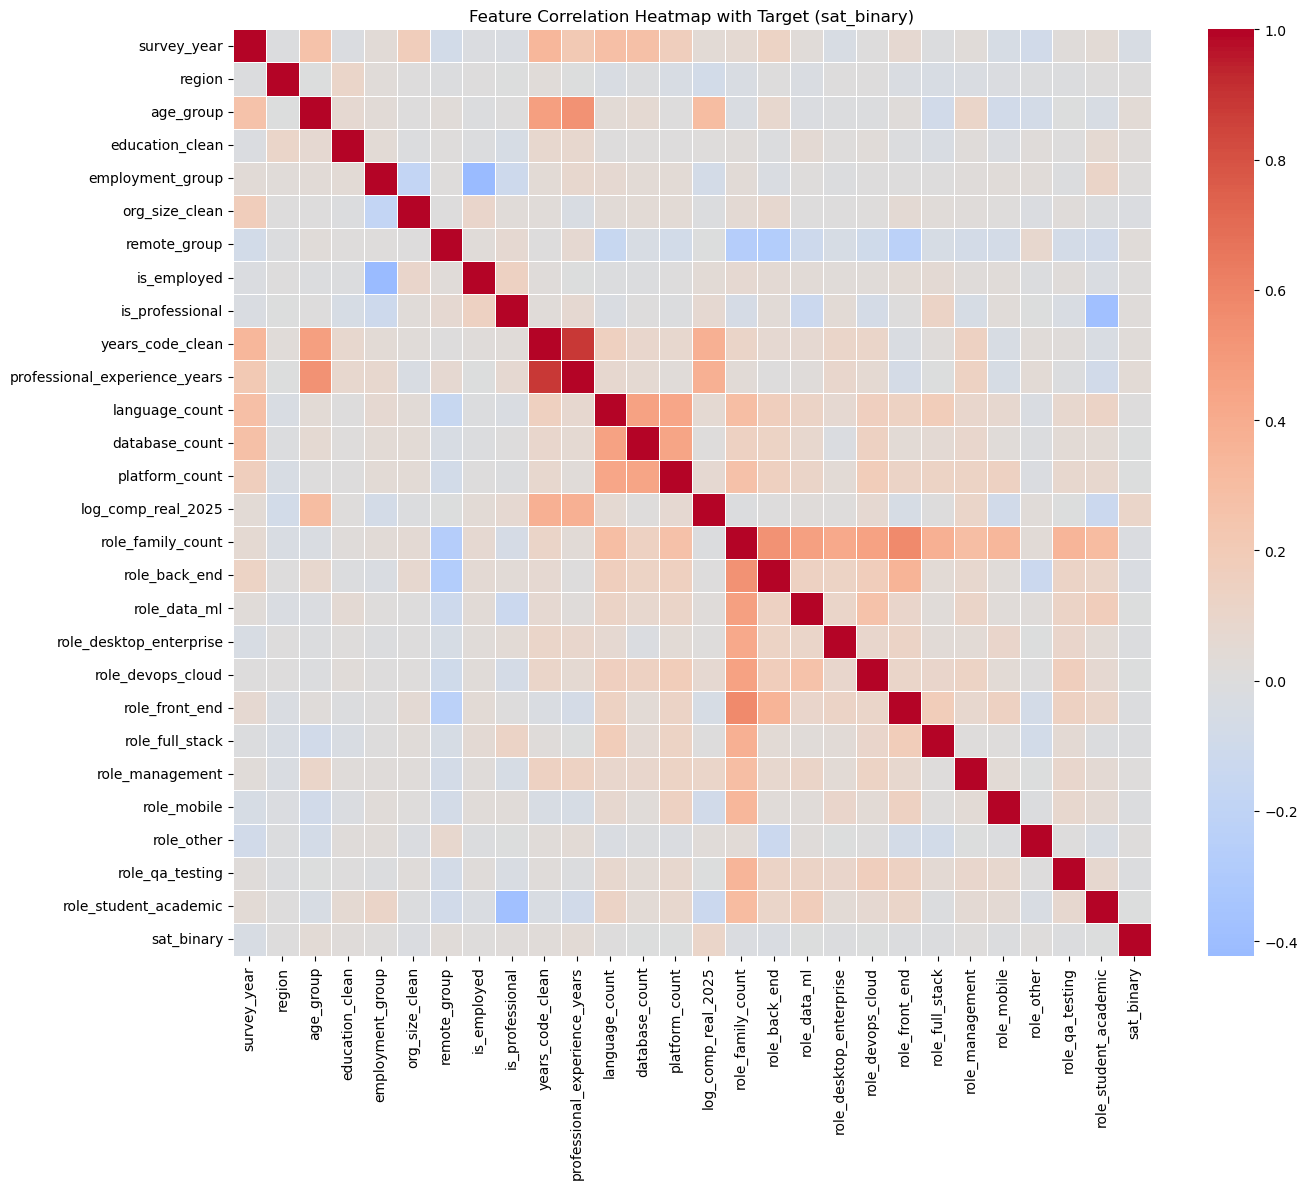

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = features + ['sat_binary']
corr_df = df_model_improved[corr_features].copy()

# Convert categoricals to numeric for correlation (if needed)
for col in cat_features:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col].astype('category').cat.codes

# Compute correlation matrix
corr = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap with Target (sat_binary)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Model Comparison Bar Charts for Metrics

Visualize metrics from the comparison DataFrame

NameError: name 'comparison' is not defined

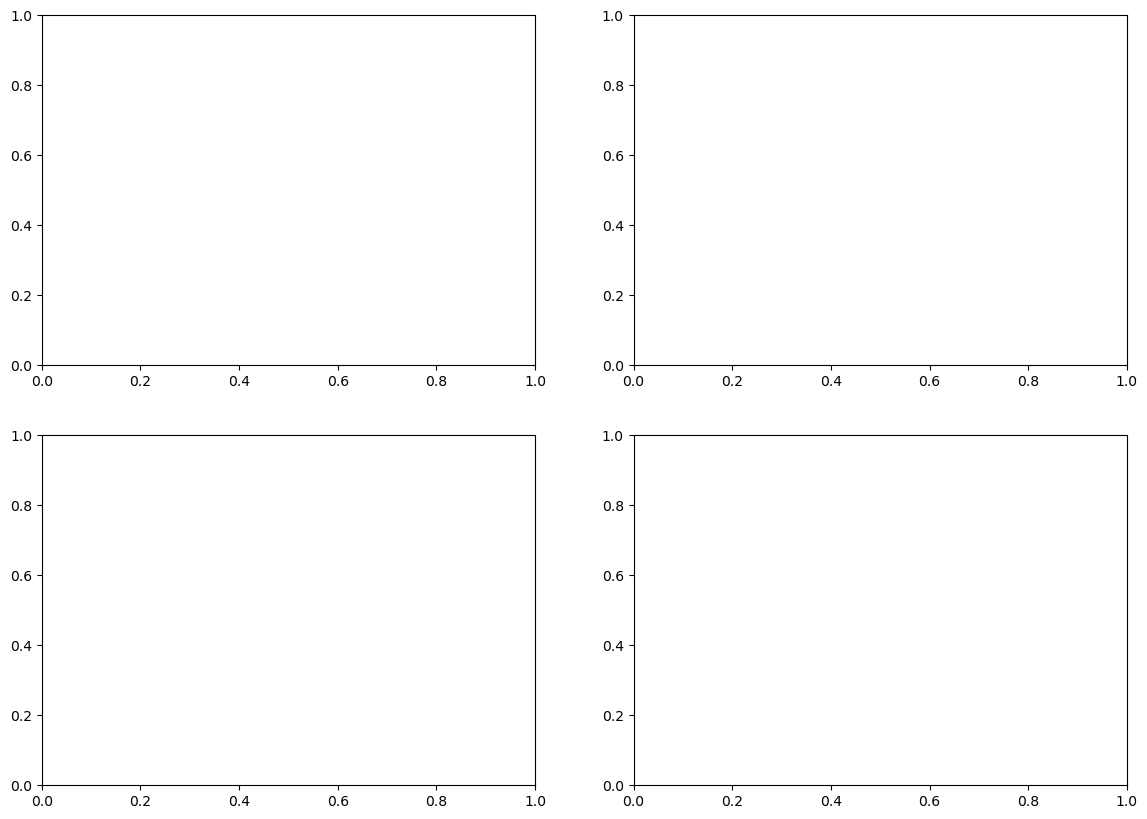

In [ ]:
import matplotlib.pyplot as plt

# Select key metrics for plotting
metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1', 'QWK']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    comparison.set_index('Model')[metric].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance Comparison', fontsize=16)
plt.tight_layout()
plt.show()